# CME Futures: GBM Regularization Grid Search

With 30 products across 7 sectors, CME futures have natural groupings that
tree splits can exploit: energy products cluster differently from rates,
and carry signals interact with sector-specific seasonality. The grid
searches 15 configurations (5 leaf-count profiles x 3 objectives) to test
whether deeper trees capture these sector interactions.

**Learning Objectives**:
- Test whether deeper trees (63 leaves) capture sector-specific carry interactions
- Compare loss functions (MSE, MAE, Huber) for heavy-tailed commodity returns
- Track IC learning curves to identify overfitting vs underfitting regimes
- Rank configs by out-of-sample IC to locate the capacity sweet spot (leaf count x loss)

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`, [`05_evaluation`](05_evaluation.ipynb)

In [1]:
"""GBM Grid Search — config-driven regularization profiles × loss functions."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml

import utils.style as style
from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    train_gbm_config,
)
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Device: read from setup.yaml, fall back to GPU detection
gbm_config = setup.get("modeling", {}).get("gbm", {})
DEVICE = gbm_config.get("device", "cuda")
MAX_BIN = 63  # GPU default
import torch

if DEVICE != "cpu" and not torch.cuda.is_available():
    DEVICE, MAX_BIN = "cpu", 255

print(f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN}")

Case study: cme_futures | Device: gpu | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 112,726 rows × 69 features
Label: fwd_ret_5d | Task: regression | Folds: 5


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

print(f"\n{len(configs)} configs × {len(splits)} folds\n")
for cfg in configs:
    leaves = cfg["params"].get("num_leaves", 31)
    obj = cfg["params"].get("objective", "regression")
    n_trees = cfg.get("max_iterations", 500)
    print(f"  {cfg['config_name']:25s}  leaves={leaves:3d}  obj={obj}  trees={n_trees}")


15 configs × 5 folds

  default_mse                leaves= 31  obj=regression  trees=500
  default_mae                leaves= 31  obj=regression_l1  trees=500
  default_huber              leaves= 31  obj=huber  trees=500
  leaves_7_mse               leaves=  7  obj=regression  trees=500
  leaves_7_mae               leaves=  7  obj=regression_l1  trees=500
  leaves_7_huber             leaves=  7  obj=huber  trees=500
  leaves_15_mse              leaves= 15  obj=regression  trees=500
  leaves_15_mae              leaves= 15  obj=regression_l1  trees=500
  leaves_15_huber            leaves= 15  obj=huber  trees=500
  leaves_31_mse              leaves= 31  obj=regression  trees=500
  leaves_31_mae              leaves= 31  obj=regression_l1  trees=500
  leaves_31_huber            leaves= 31  obj=huber  trees=500
  leaves_63_mse              leaves= 63  obj=regression  trees=500
  leaves_63_mae              leaves= 63  obj=regression_l1  trees=500
  leaves_63_huber            leaves= 63  obj

## 2. Prepare CV Folds

GBM folds use float32 (LightGBM native precision) and skip
imputation/scaling — gradient boosting handles missing values natively.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=60,721  val=7,668
  Fold 1: train=60,367  val=7,684
  Fold 2: train=60,074  val=7,676
  Fold 3: train=59,801  val=7,674
  Fold 4: train=58,942  val=7,692


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations) to
detect overfitting — configs that peak early and decay indicate too much capacity.

In [7]:
results = []
for cfg in configs:
    # Pre-compute registry training dir so boosters go directly there
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _status = training_run_status(CASE_STUDY_ID, spec)
    _training_hash = training_hash_from_spec(spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        # Already trained + registered: rebuild a minimal result from the
        # registry so the grid + learning-curve sections render on a
        # fully-cached checkout. (A bare `continue` here drops the config
        # from `results`, printing an empty grid when every config is
        # registered.) best_ic is the authoritative registered value;
        # best_iter and the curves come from learning_curves.parquet.
        _pred_hash = _split_rows["prediction_hash"][0]
        _metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=_pred_hash)
        _best_ic = float(_metrics["ic_mean"][0]) if not _metrics.is_empty() else float("nan")
        _curves = []
        _lc_path = train_dir / "learning_curves.parquet"
        if _lc_path.exists():
            _curves = pl.read_parquet(_lc_path).to_dicts()
        _best_iter = 0
        if _curves:
            _best_iter = int(max(_curves, key=lambda c: c["ic_mean"])["iteration"])
        print(
            f"  {cfg['config_name']:25s}  iter={_best_iter:4d}  IC={_best_ic:+.4f}  "
            f"(cached, {_status.summary()})"
        )
        results.append(
            {
                "config_name": cfg["config_name"],
                "best_iter": _best_iter,
                "best_ic": _best_ic,
                "elapsed_s": 0.0,
                "learning_curves": _curves,
                "cached": True,
            }
        )
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN — missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN — partial state: {_status.summary()}")

    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({result['elapsed_s']:.0f}s)"
    )

    # Register immediately after training — incremental save protects against
    # interruption losing work on large sweeps.
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
    )

  default_mse                iter= 250  IC=+0.0148  (cached, complete (hash=82c0e4e03baa))
  default_mae                iter=  50  IC=+0.0046  (cached, complete (hash=ca4b3a8b1e69))
  default_huber              iter= 250  IC=+0.0148  (cached, complete (hash=d801ed40898d))
  leaves_7_mse               iter= 350  IC=+0.0146  (cached, complete (hash=d0b690751192))
  leaves_7_mae               iter= 450  IC=+0.0232  (cached, complete (hash=5a19e6a68e24))
  leaves_7_huber             iter= 350  IC=+0.0146  (cached, complete (hash=5423eddea8d6))
  leaves_15_mse              iter= 450  IC=+0.0231  (cached, complete (hash=b3c3d02f8cb5))
  leaves_15_mae              iter= 350  IC=+0.0165  (cached, complete (hash=b6ea718dcb7e))
  leaves_15_huber            iter= 450  IC=+0.0231  (cached, complete (hash=b9364be39288))
  leaves_31_mse              iter= 400  IC=+0.0252  (cached, complete (hash=543218cd01eb))
  leaves_31_mae              iter=  50  IC=+0.0140  (cached, complete (hash=b9a4fe03c54c))

## 4. Grid Results

All configs ranked by peak IC (best checkpoint). Every config's
best-checkpoint validation predictions are registered (Section 3); the
cross-stage backtest sweep — not a single-IC pick here — chooses the carrier
downstream, so the `*` marks the IC leader for reference, not the final winner.

In [8]:
results.sort(key=lambda r: r["best_ic"], reverse=True)
best = results[0] if results else None

print(f"{'Config':25s}  {'Iter':>5s}  {'IC':>8s}  {'Time':>6s}")
print("-" * 50)
for r in results:
    marker = " *" if r is best else ""
    print(
        f"  {r['config_name']:25s}  {r['best_iter']:5d}  {r['best_ic']:+.4f}  {r['elapsed_s']:5.0f}s{marker}"
    )

if best:
    print(f"\nBest: {best['config_name']} @ {best['best_iter']} trees (IC={best['best_ic']:+.4f})")

Config                      Iter        IC    Time
--------------------------------------------------
  leaves_31_mse                400  +0.0252      0s *
  leaves_63_mae                450  +0.0246      0s
  leaves_7_mae                 450  +0.0232      0s
  leaves_15_mse                450  +0.0231      0s
  leaves_15_huber              450  +0.0231      0s
  leaves_31_huber              150  +0.0204      0s
  leaves_15_mae                350  +0.0165      0s
  default_huber                250  +0.0148      0s
  default_mse                  250  +0.0148      0s
  leaves_7_huber               350  +0.0146      0s
  leaves_7_mse                 350  +0.0146      0s
  leaves_31_mae                 50  +0.0140      0s
  leaves_63_mse                450  +0.0134      0s
  leaves_63_huber              500  +0.0129      0s
  default_mae                   50  +0.0046      0s

Best: leaves_31_mse @ 400 trees (IC=+0.0252)


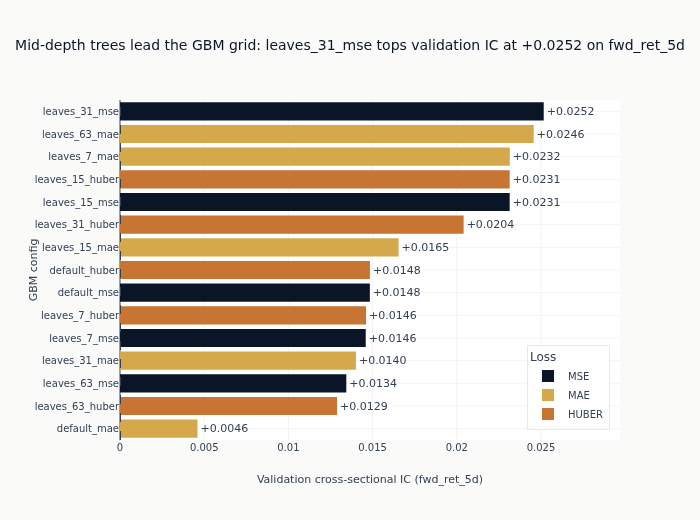

In [9]:
# Grid IC as a chart: one bar per config, hue by loss function, sorted so the
# leader sits on top. The dashed line at zero is the credibility reference —
# a validation IC whose sign is not distinguishable from zero carries no
# standalone edge (the HAC intervals live in 12_model_analysis).
_LOSS_HUE = {
    "mse": style.COLORS["blue"],
    "mae": style.COLORS["amber"],
    "huber": style.COLORS["copper"],
}


def _loss_of(name: str) -> str:
    return next((loss for loss in _LOSS_HUE if name.endswith(loss)), "mse")


if results:
    _ranked = sorted(results, key=lambda r: r["best_ic"])  # ascending -> best on top
    _names = [r["config_name"] for r in _ranked]
    _ics = [r["best_ic"] for r in _ranked]
    _losses = [_loss_of(n) for n in _names]

    fig = go.Figure()
    for loss, hue in _LOSS_HUE.items():
        idx = [i for i, ls in enumerate(_losses) if ls == loss]
        if not idx:
            continue
        fig.add_bar(
            x=[_ics[i] for i in idx],
            y=[_names[i] for i in idx],
            orientation="h",
            marker_color=hue,
            name=loss.upper(),
            text=[f"{_ics[i]:+.4f}" for i in idx],
            textposition="outside",
            cliponaxis=False,
        )
    fig.add_vline(x=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
    # One IC per config, so category "total" == the config's own IC: sort the
    # whole grid globally (leader on top) while keeping the 3 loss legend hues.
    fig.update_yaxes(categoryorder="total ascending")
    fig.update_layout(
        template="ml4t",
        title=(
            f"Mid-depth trees lead the GBM grid: {best['config_name']} tops "
            f"validation IC at {best['best_ic']:+.4f} on {label_col}"
        ),
        xaxis_title=f"Validation cross-sectional IC ({label_col})",
        yaxis_title="GBM config",
        legend_title="Loss",
        legend=dict(x=0.98, y=0.03, xanchor="right", yanchor="bottom"),
        margin=dict(l=120),
        height=520,
    )
    # Headroom on the right so the outside value labels are not clipped.
    fig.update_xaxes(range=[0, max(_ics) * 1.18])
    fig.show()

## 5. Learning Curves

IC at checkpoints (every 50 iterations) for each config. Configs that peak
early and decay indicate overfitting; those that plateau show good regularization.

In [10]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
if all_curves.height > 0:
    checkpoints = sorted(all_curves["iteration"].unique().to_list())
    display_cps = [cp for cp in [50, 100, 200, 300, 500] if cp in checkpoints]

    print(f"{'Config':25s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()

    for r in results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"])
        print(f"  {r['config_name']:25s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("iteration") == cp)
            if row.height > 0:
                print(f" {row['ic_mean'][0]:+7.4f}", end="")
            else:
                print(f" {'N/A':>7s}", end="")
        print()

Config                         50     100     200     300     500
  leaves_31_mse             +0.0121 +0.0188 +0.0226 +0.0242 +0.0220
  leaves_63_mae             +0.0044 +0.0089 +0.0179 +0.0222 +0.0215
  leaves_7_mae              -0.0101 -0.0047 +0.0076 +0.0130 +0.0223
  leaves_15_mse             +0.0044 +0.0146 +0.0218 +0.0228 +0.0231
  leaves_15_huber           +0.0044 +0.0146 +0.0218 +0.0228 +0.0231
  leaves_31_huber           +0.0121 +0.0188 +0.0202 +0.0161 +0.0172
  leaves_15_mae             +0.0018 +0.0018 +0.0076 +0.0147 +0.0147
  default_huber             +0.0115 +0.0106 +0.0146 +0.0141 +0.0110
  default_mse               +0.0115 +0.0106 +0.0146 +0.0141 +0.0122
  leaves_7_huber            -0.0124 -0.0029 +0.0063 +0.0087 +0.0103
  leaves_7_mse              -0.0124 -0.0029 +0.0063 +0.0087 +0.0103
  leaves_31_mae             +0.0140 +0.0105 +0.0104 +0.0113 +0.0129
  leaves_63_mse             +0.0010 +0.0018 +0.0089 +0.0132 +0.0125
  leaves_63_huber           +0.0010 -0.0003 +0.008

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
This protects against interruption — all completed configs are already
persisted in `run_log/registry.db`.

In [11]:
print(f"All {len(results)} configs registered.")

All 15 configs registered.


## 7. Key Takeaways

The GBM grid clusters most configurations between +0.013 and +0.025 IC on
`fwd_ret_5d`, with the highest-IC config `leaves_31_mse` at IC +0.0252
(HAC 95% CI [-0.002, +0.053], $t_{HAC}=1.80$; see
[`12_model_analysis`](12_model_analysis.ipynb)). The interval still includes
zero, so no GBM config clears the credibility line at this sample size on the
primary label. Neither leaf count nor loss orders the grid cleanly: the top
cluster (+0.023 to +0.025) mixes 15-, 31-, and 63-leaf profiles and both MSE
and MAE, and the IC spread across all 15 configs is small relative to the HAC
uncertainty. On a 30-product cross-section the trees have little stable
non-linear structure to separate, so the IC ranking is noisy and a single
best-by-IC pick is not robust. GBM's value therefore resolves at the strategy
stage rather than at IC alone: in [`13_backtest`](13_backtest.ipynb) the
cross-stage sweep — ranking by Sharpe, not IC — carries `gbm/leaves_7_huber`
on `fwd_ret_5d` (a low-but-positive IC of +0.0146) to the validation Sharpe
lead (1.26), a result the sealed holdout confirms in
[`17_strategy_analysis`](17_strategy_analysis.ipynb) (Sharpe 1.14).